# TCN with Dilated Convolutions for Heart Rate Interval Segmentation

**Master's Thesis Implementation**

This notebook implements a Temporal Convolutional Network (TCN) with dilated convolutions and residual connections for detecting workout interval boundaries from heart rate data.

Run all cells from top to bottom.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import os
from typing import Dict, List, Tuple
from dataclasses import dataclass
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

RANDOM_SEED = 123
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")
print("Imports complete")

TensorFlow version: 2.20.0
Imports complete


## 2. Configuration

In [2]:
@dataclass
class Config:
    """Configuration for the segmentation pipeline."""
    random_seed: int = 123
    
    # Feature engineering
    # These define the time windows used to calculate statistical features from HR data
    short_window: int = 20
    medium_window: int = 30
    long_window: int = 60
    
    # Model
    model_type: str = "xgboost"
    xgb_max_depth: int = 6 # Maximum depth of each decision tree (higher = more complex, risk of overfitting)
    xgb_n_estimators: int = 400 # Number of boosting rounds/trees to build
    xgb_learning_rate: float = 0.03 # Step size for each tree's contribution
    xgb_scale_pos_weight: float = 30.0 # Weight multiplier for positive class (boundaries) to handle class imbalance
    
    # Post-processing
    peak_distance: int = 20 # Minimum time between detected interval boundaries
    peak_prominence: float = 0.15 # Minimum prominence of probability peaks to be considered a boundary
    smooth_sigma: float = 3.0 # Default sigma; actual sigma is chosen adaptively in detect_peaks

    # TCN specific
    segment_length: int = 300      # 5 minutes at 1Hz
    segment_overlap: int = 225     # 75% overlap for smoother probability averaging
    tcn_epochs: int = 50
    tcn_batch_size: int = 32
    tcn_patience: int = 15
    tcn_n_filters: int = 64
    tcn_kernel_size: int = 3
    tcn_n_layers: int = 7          # dilations: 1, 2, 4, 8, 16, 32, 64 → RF = 509 steps
    tcn_dropout: float = 0.35      # increased from 0.2 to reduce overfitting

CONFIG = Config()
print(f"✓ Configuration set (model: {CONFIG.model_type})")

✓ Configuration set (model: xgboost)


## 3. Data Configuration

In [3]:
# Your athlete data
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all"
    },

    "AthletesSpecialBike": {
        "sport": "biking",
        "ftp": None,
        "fit_dir": None,
        "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Biking/GTs",
        "allowed_files": "all"
    },

    "AthletesSpecialRowing": {
    "sport": "rowing",
    "ftp": None,
    "fit_dir": None,
    "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Rowing/GTs",
    "allowed_files": "all"
    }
}

# Test sessions (held out for evaluation)
test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
    ("Athlete12", "12069656901_Schwitzen_im_Sitzen"),
    ("Athlete12", "12989160676_Wohnzimmerromantik"),
    ("Athlete12", "14089880174_Zn_IKEA"),
    ("AthletesSpecialBike", "6697827529_Zwift__VO2max_1h110"),
    ("AthletesSpecialBike", "14691322045_Zwift__3x12min_3030_4x2min_Vo2Max_on_Road_to_Sky_in_Watopia"),
    ("AthletesSpecialBike", "10283878603_Zwift__HIT__HIT_EB_5x3_min_in_Watopia"),
    ("AthletesSpecialBike", "13557212506_Zwift__HIT__HIT_EB_7x2_min_VLamax_Pusher_in_Watopia"),
    ("AthletesSpecialRowing", "14612015090_3x_6x_3030")
]

print(f"✓ Data configuration loaded")
print(f"  Athletes: {list(athletes.keys())}")
print(f"  Test sessions: {len(test_sessions)}")

✓ Data configuration loaded
  Athletes: ['Athlete12', 'Athlete2', 'AthletesSpecialBike', 'AthletesSpecialRowing']
  Test sessions: 19


## 4. Feature Engineering

In [4]:
def create_hr_features(df: pd.DataFrame, config: Config, n_expected_intervals: int = None) -> pd.DataFrame:

    # Initialize empty DataFrame to store all engineered features (preserves original index/timestamps)
    features = pd.DataFrame(index=df.index)

    # Extract heart rate values as numpy array for faster computation
    hr = df['heart_rate'].values

    # ==================== SESSION-LEVEL STATISTICS ====================
    # Calculate global statistics across the entire workout session
    # These provide context about the overall intensity and variability of the workout
    session_mean = hr.mean()           # Average HR for the session (baseline fitness reference)
    session_std = hr.std()             # Standard deviation (measure of HR variability)
    session_max = hr.max()             # Peak HR reached during session
    session_min = hr.min()             # Lowest HR (typically resting/recovery)
    session_range = session_max - session_min  # Total HR range (intensity span)
    session_p25 = np.percentile(hr, 25)  # 25th percentile (lower quartile - recovery zones)
    session_p75 = np.percentile(hr, 75)  # 75th percentile (upper quartile - high intensity zones)
    session_iqr = session_p75 - session_p25  # Interquartile range (robust measure of spread)

    # ==================== INTERVAL DENSITY FEATURES (Top 2) ====================
    # These features capture workout structure/pacing information
    if n_expected_intervals is not None:
        session_duration = (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0]).total_seconds()  # Total number of seconds in the workout
        # Average length of each interval in seconds (helps model understand workout density)
        expected_interval_length = session_duration / n_expected_intervals
        # How many intervals occur per minute (pacing metric: high = short intervals, low = long intervals)
        intervals_per_minute = n_expected_intervals / (session_duration / 60)

        features['intervals_per_minute'] = intervals_per_minute  # Rank 1 - Most important feature (0.1135)
        features['expected_interval_length'] = expected_interval_length  # Rank 2 - Second most important (0.0714)

    # ==================== SMOOTHED HR ====================
    # Apply rolling averages to reduce noise and reveal underlying trends
    # center=True: window is centered on current point (uses past and future data)
    # min_periods=1: compute even at edges where full window isn't available
    features['hr_smooth_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).mean()
    features['hr_smooth_long'] = df['heart_rate'].rolling(window=config.long_window, center=True, min_periods=1).mean()

    # ==================== NORMALIZED HR FEATURES ====================
    # Z-score normalization: converts HR to "standard deviations from mean"
    # Makes features comparable across different individuals/fitness levels
    # +1e-6 prevents division by zero if std is 0
    features['hr_smooth_medium_normalized'] = (features['hr_smooth_medium'] - session_mean) / (session_std + 1e-6)  # Rank 3

    # ==================== TEMPORAL FEATURES ====================
    # Look-ahead features: what is the HR going to be in the future?
    # Negative shift means "look forward in time"
    # These are powerful because boundaries show different HR 30-60s later
    features['hr_lead_30s'] = df['heart_rate'].shift(-30)  # HR 30 seconds in the future - Rank 4
    features['hr_lead_60s'] = df['heart_rate'].shift(-60)  # HR 60 seconds in the future - Rank 5

    # ==================== ROLLING STATISTICS ====================
    # Calculate statistics over medium-sized windows (40s by default)
    features['hr_max_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).max()
    features['hr_min_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).min()
    # Range within the window (high range = variable/transitioning HR, low range = steady state)
    features['hr_range_medium'] = features['hr_max_medium'] - features['hr_min_medium']  # Rank 6
    # Standard deviation within window (another variability measure)
    features['hr_std_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).std()

    # ==================== RELATIVE FEATURES ====================
    # Difference from long-term baseline (detects deviations from sustained HR level)
    # Positive = above baseline (working hard), negative = below baseline (recovering)
    features['hr_vs_long_baseline'] = hr - features['hr_smooth_long']  # Rank 7

    # ==================== SESSION-NORMALIZED FEATURES ====================
    # Compare current HR to key session statistics
    features['hr_vs_session_p75'] = hr - session_p75  # Rank 8 - Distance from high-intensity threshold

    # Change from past to future (60s lag to 60s lead = 120s total span)
    # Large positive = HR is rising dramatically, large negative = HR is dropping
    features['hr_change_past_to_future'] = features['hr_lead_60s'] - df['heart_rate'].shift(60)
    features['hr_change_past_to_future_normalized'] = features['hr_change_past_to_future'] / (session_std + 1e-6)  # Rank 9

    # Where in the session's range are we? (0 = at min, 1 = at max)
    features['hr_pct_of_session_range'] = (hr - session_min) / (session_range + 1e-6)  # Rank 11
    # What percentage of max HR? (intensity metric)
    features['hr_pct_of_session_max'] = hr / (session_max + 1e-6)  # Rank 12

    # ==================== DERIVATIVES ====================
    # Rate of change over different time scales (velocity of HR change)
    features['hr_diff_5s'] = df['heart_rate'].diff(5)    # Short-term change (5 seconds)
    features['hr_diff_10s'] = df['heart_rate'].diff(10)  # Medium-term change (10 seconds)
    features['hr_diff_30s'] = df['heart_rate'].diff(30)  # Long-term change (30 seconds)

    # Normalized derivatives (makes comparable across different session variabilities)
    features['hr_diff_10s_normalized'] = features['hr_diff_10s'] / (session_std + 1e-6)  # Rank 13

    # Direct change from historical points (alternative to diff())
    features['hr_change_from_lag60'] = hr - df['heart_rate'].shift(60)  # Rank 14 - Change over last 60s
    features['hr_change_from_lag30'] = hr - df['heart_rate'].shift(30)  # Change over last 30s
    features['hr_diff_30s_normalized'] = features['hr_diff_30s'] / (session_std + 1e-6)  # Rank 15

    # ==================== TREND INDICATORS ====================
    # Binary feature: is HR currently increasing?
    # 1 = rising, 0 = falling or steady
    features['hr_increasing'] = (features['hr_diff_10s'] > 0).astype(int)  # Rank 10

    # ==================== SESSION CONTEXT ====================
    # Flag for high-density workouts (≥20 intervals)
    # These might have different boundary characteristics than low-density workouts
    if n_expected_intervals is not None:
        features['is_high_density_session'] = (n_expected_intervals >= 20).astype(int)  # Rank 16

    # More session comparison features
    features['hr_vs_session_mean'] = hr - session_mean  # Rank 17 - Distance from average
    features['hr_vs_session_p25'] = hr - session_p25    # Rank 18 - Distance from low-intensity threshold
    features['hr_pct_of_session_mean'] = hr / (session_mean + 1e-6)  # Rank 19 - Ratio to average

    # ==================== REMAINING FEATURES (Ranks 20-30) ====================
    # Maximum HR in short window (captures local peaks)
    features['hr_max_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).max()

    # Zone indicators (binary features for different intensity zones)
    features['in_max_zone'] = (hr > (session_mean + session_std)).astype(int)  # In high-intensity zone (>1 std above mean)
    features['in_low_zone'] = (hr < session_p25).astype(int)  # In recovery/low zone (<25th percentile)

    # Historical HR values (what was HR 30s ago?)
    features['hr_lag_30s'] = df['heart_rate'].shift(30)
    features['hr_lag_30s_normalized'] = (features['hr_lag_30s'] - session_mean) / (session_std + 1e-6)

    # Z-score of current HR (standardized deviation from mean)
    features['hr_zscore_session'] = (hr - session_mean) / (session_std + 1e-6)

    # Percentage change over 30s (relative rate of change)
    features['hr_pct_change_30s'] = df['heart_rate'].pct_change(30) * 100

    # Session-level constants (same value for all rows, provides scaling context to model)
    features['session_hr_std'] = session_std
    features['session_hr_iqr'] = session_iqr
    features['session_hr_mean'] = session_mean

    # ==================== CLEAN UP ====================
    # Replace infinite values with NaN (can occur from division operations)
    features = features.replace([np.inf, -np.inf], np.nan)
    # Forward fill then backward fill NaN values (propagate valid values)
    # Finally fill any remaining NaN with 0
    features = features.fillna(method='ffill').fillna(method='bfill').fillna(0)

    return features

## 5. Post-Processing

In [5]:
def detect_peaks_with_constraint(probabilities: np.ndarray, n_expected_intervals: int, config: Config) -> np.ndarray:
    """Detect peaks in probability signal with constraint on number of intervals."""

    # SIMPLER adaptive peak_distance (closer to your original)
    if n_expected_intervals >= 35:
        peak_distance = 5  # Ultra high density
    elif n_expected_intervals >= 25:
        peak_distance = 8
    elif n_expected_intervals >= 20:
        peak_distance = 10
    elif n_expected_intervals >= 15:
        peak_distance = 15
    elif n_expected_intervals >= 10:
        peak_distance = 20
    else:
        peak_distance = config.peak_distance  # 30s default

    # Adaptive smoothing: dense sessions need sharper peaks, sparse sessions tolerate more smoothing
    session_duration = len(probabilities)
    avg_interval_len = session_duration / n_expected_intervals
    if avg_interval_len < 60:
        sigma = 1.5   # Short intervals: keep peaks sharp
    elif avg_interval_len < 180:
        sigma = config.smooth_sigma  # Default (3.0)
    else:
        sigma = 5.0   # Long intervals: smooth more aggressively

    probs_smooth = gaussian_filter1d(probabilities, sigma=sigma)

    # ALWAYS START WITH INDEX 0
    forced_peaks = [0]
    n_remaining = n_expected_intervals - 1

    # Find peaks
    peaks, properties = find_peaks(
        probs_smooth[peak_distance:],
        distance=peak_distance,
        prominence=config.peak_prominence
    )
    peaks = peaks + peak_distance

    if len(peaks) == n_remaining:
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too many peaks - keep N-1 highest
    if len(peaks) > n_remaining:
        peak_heights = probs_smooth[peaks]
        top_n_indices = np.argsort(peak_heights)[-n_remaining:]
        peaks = peaks[top_n_indices]
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too few peaks - try without prominence ONLY
    if len(peaks) < n_remaining:
        peaks, _ = find_peaks(probs_smooth[peak_distance:], distance=peak_distance)
        peaks = peaks + peak_distance

        if len(peaks) >= n_remaining:
            peak_heights = probs_smooth[peaks]
            top_n_indices = np.argsort(peak_heights)[-n_remaining:]
            peaks = peaks[top_n_indices]
            return np.sort(np.concatenate([forced_peaks, peaks]))

        # Last resort - your original approach
        top_indices = np.argsort(probs_smooth[peak_distance:])[-n_remaining * 3:][::-1] + peak_distance
        selected = []
        for idx in top_indices:
            if all(abs(idx - s) >= peak_distance for s in selected):
                selected.append(idx)
            if len(selected) == n_remaining:
                break
        return np.sort(np.concatenate([forced_peaks, selected]))

    return np.sort(np.concatenate([forced_peaks, peaks]))

## 6. Evaluation

In [6]:
def evaluate_with_tolerance(y_true: np.ndarray, y_pred: np.ndarray,
                                       tolerance_before: int = 10,
                                       tolerance_after: int = 10) -> Dict:
    """
    Evaluate predictions with time tolerance.
    Uses F_beta score with beta=2 (emphasizes recall 2:1 over precision).
    """
    true_boundaries = np.where(y_true == 1)[0]
    pred_boundaries = np.where(y_pred == 1)[0]

    # Match predictions to ground truth (within window)
    matched_preds = 0
    for pred_idx in pred_boundaries:
        for true_idx in true_boundaries:
            # Check if prediction is within [-3s, +7s] of ground truth
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                matched_preds += 1
                break  # Count this prediction only once

    # Match ground truth to predictions (within window)
    matched_true = 0
    for true_idx in true_boundaries:
        for pred_idx in pred_boundaries:
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                matched_true += 1
                break  # Count this GT only once

    n_true = len(true_boundaries)
    n_pred = len(pred_boundaries)

    # Standard precision and recall
    precision = matched_preds / n_pred if n_pred > 0 else 0
    recall = matched_true / n_true if n_true > 0 else 0

    # F_beta score with beta=√2 ≈ 1.41 (weighs recall 2x more than precision)
    beta = np.sqrt(2)  # Beta² = 2, so recall is weighted 2:1 over precision
    f_beta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall) if (beta**2 * precision + recall) > 0 else 0

    # Average time error for matched predictions
    errors = []
    for pred_idx in pred_boundaries:
        distances = np.abs(true_boundaries - pred_idx)
        errors.append(distances.min())

    mean_error = np.mean(errors) if errors else 0

    return {
        'precision': precision,
        'recall': recall,
        'f_beta': f_beta,  # This is your 2:1 recall-weighted F-score
        'n_true': n_true,
        'n_pred': n_pred,
        'mean_error_sec': mean_error
    }

## 7. Data Loading

In [7]:
def load_all_sessions(athletes: dict) -> Dict[Tuple[str, str], pd.DataFrame]:
    """Load all session data."""
    session_data = {}
    
    for athlete, meta in athletes.items():
        label_dir = meta["label_dir"]
        allowed = meta["allowed_files"]
        
        if allowed == "all":
            csv_files = [f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")]
        else:
            csv_files = [f.replace(".fit", "_with_manual_labels.csv") for f in allowed]
        
        for filename in csv_files:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path):
                continue
            
            try:
                df = pd.read_csv(file_path)
                df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
                df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)
                df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
                df.loc[0, 'manual_timestamp_numerical'] = 1
                last_5_sec_idx = len(df) - 5
                if last_5_sec_idx > 0:
                    df.loc[last_5_sec_idx:, 'manual_timestamp_numerical'] = 0
                df['heart_rate'] = df['heart_rate'].fillna(method='ffill').fillna(method='bfill')
                df['power'] = df['power'].rolling(5, center=True, min_periods=1).mean()
                
                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = df
                print(f"✓ {athlete} - {session_name[:40]}")
            except Exception as e:
                print(f"❌ Error loading {filename}: {e}")
    
    return session_data

print("\n📂 Loading session data...")
hr_session_data = load_all_sessions(athletes)
print(f"\n✓ Loaded {len(hr_session_data)} sessions total")


📂 Loading session data...
✓ Athlete12 - 13983533934_Technik__30er
✓ Athlete12 - 13974345688_Nochmaaaal
✓ Athlete12 - 12927701413_I_have_no_idea_when_Ill_be_b
✓ Athlete12 - 13971240869_A_ella_le_gusta
✓ Athlete12 - 13582048984_W_Up
✓ Athlete12 - 14135321532_Pimp_my_ride
✓ Athlete12 - 13643807487_Nachfitten
✓ Athlete12 - 11636429453_4558_row
✓ Athlete12 - 11846980624_Platt_
✓ Athlete12 - 13610691264_1x_Crescendo
✓ Athlete12 - 14313279747_Vernunft_verliert_
✓ Athlete12 - 13363035398_SGAktiv
✓ Athlete12 - 12501679452_Zustand_nach_Xtem_Atemwegsin
✓ Athlete12 - 11962243206_Wundmanagement
✓ Athlete12 - 12846436186_Synchronflug
✓ Athlete12 - 12951604563_DienstSport
✓ Athlete12 - 10551999765_10006_row
✓ Athlete12 - 11912062341_500er_in_grau
✓ Athlete12 - 13662882990_Heldentod
✓ Athlete12 - 12069656901_Schwitzen_im_Sitzen
✓ Athlete12 - 11971395278_Use_it_or_lose_it
✓ Athlete12 - 12806981726_Row_Stretch__Stabi
✓ Athlete12 - 13300350440_W_Up
✓ Athlete12 - 14001095362_Wer_will_der_kann_
✓ Athlete1

## 8. Prepare Train/Test Data

In [8]:
print("\n🔧 Preparing train/test datasets...")

train_sessions = []
test_sessions_data = []

# Sport counters
train_sport_count = {'biking': 0, 'rowing': 0}
test_sport_count = {'biking': 0, 'rowing': 0}

# Track which test sessions were found
found_test_sessions = set()

# Loop through all sessions and prepare features + labels
for (athlete, session), df in hr_session_data.items():
    y = df['manual_timestamp_numerical'].values
    n_intervals = y.sum()

    features_df = create_hr_features(df, CONFIG, n_intervals)
    X = features_df.values

    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        print(f"⚠️  Skipping {session} - invalid values")
        continue

    sport = athletes[athlete]['sport']

    session_info = {
        'athlete': athlete,
        'session': session,
        'sport': sport,
        'X': X,
        'y': y,
        'n_intervals': n_intervals,
        'duration_sec': len(y),
        'feature_names': features_df.columns.tolist(),
        'df': df
    }

    if (athlete, session) in test_sessions:
        test_sessions_data.append(session_info)
        test_sport_count[sport] += 1
        found_test_sessions.add((athlete, session))
    else:
        train_sessions.append(session_info)
        train_sport_count[sport] += 1

missing_test_sessions = set(test_sessions) - found_test_sessions

if missing_test_sessions:
    print("\n❌ WARNING: The following test sessions were NOT FOUND:")
    for athlete, session in missing_test_sessions:
        sport = athletes.get(athlete, {}).get('sport', 'unknown')
        print(f"   {athlete} ({sport}): {session}")
else:
    print("\n✓ All test sessions found successfully")

X_train = np.vstack([s['X'] for s in train_sessions])
y_train = np.concatenate([s['y'] for s in train_sessions])

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

for session in test_sessions_data:
    session['X'] = scaler.transform(session['X'])

# Also update individual train session arrays with scaled features (needed for segment creation)
offset = 0
for session in train_sessions:
    n = len(session['y'])
    session['X'] = X_train[offset:offset+n]
    offset += n

print(f"\n✓ Dataset prepared:")
print(f"   Training sessions: {len(train_sessions)}")
print(f"     - Biking: {train_sport_count['biking']}")
print(f"     - Rowing: {train_sport_count['rowing']}")
print(f"   Test sessions: {len(test_sessions_data)}")
print(f"     - Biking: {test_sport_count['biking']}")
print(f"     - Rowing: {test_sport_count['rowing']}")
print(f"   Training samples: {len(X_train):,} ({y_train.sum()} positive)")
print(f"   Features: {X_train.shape[1]}")


🔧 Preparing train/test datasets...

❌ WARNING: The following test sessions were NOT FOUND:
   Athlete12 (rowing): 12989160676_Wohnzimmerromantik

✓ Dataset prepared:
   Training sessions: 75
     - Biking: 24
     - Rowing: 51
   Test sessions: 18
     - Biking: 6
     - Rowing: 12
   Training samples: 278,990 (1428 positive)
   Features: 39


## 9. Prepare TCN Segments

In [9]:
def prepare_segments(sessions, seg_len, overlap):
    """Create overlapping segments for training."""
    all_X, all_y = [], []
    stride = seg_len - overlap
    for s in sessions:
        X, y = s['X'], s['y']
        for i in range((len(X) - seg_len) // stride + 1):
            start = i * stride
            end = start + seg_len
            if end <= len(X):
                all_X.append(X[start:end])
                all_y.append(y[start:end])
    return np.array(all_X), np.array(all_y)

# Session-level validation split (~15% of training sessions)
# Fixed seed before shuffle for reproducibility
np.random.seed(CONFIG.random_seed)
n_val = max(1, int(len(train_sessions) * 0.15))
np.random.shuffle(train_sessions)
val_sessions = train_sessions[:n_val]
actual_train_sessions = train_sessions[n_val:]

X_train_seg, y_train_seg = prepare_segments(actual_train_sessions, CONFIG.segment_length, CONFIG.segment_overlap)
X_val_seg, y_val_seg = prepare_segments(val_sessions, CONFIG.segment_length, CONFIG.segment_overlap)

# Expand labels to (batch, time, 1) for Conv1D output
y_train_seg = y_train_seg[..., np.newaxis]
y_val_seg = y_val_seg[..., np.newaxis]

# Apply Gaussian label smoothing to training labels only.
# Spreads each boundary spike into a soft Gaussian bump (sigma=5s ≈ ±10s window),
# aligning the training target with the evaluation tolerance.
from scipy.ndimage import gaussian_filter1d as _gf1d
y_train_seg_smooth = np.zeros_like(y_train_seg, dtype=np.float32)
for i in range(len(y_train_seg)):
    y_train_seg_smooth[i, :, 0] = np.clip(_gf1d(y_train_seg[i, :, 0].astype(float), sigma=5), 0, 1)
y_train_seg = y_train_seg_smooth

n_features = X_train_seg.shape[2]
print(f"Train segments: {X_train_seg.shape}")
print(f"Val segments: {X_val_seg.shape}")
print(f"Train positive mass: {y_train_seg.sum():.1f} (smoothed) over {y_train_seg.size} samples")
print(f"Val sessions: {n_val}, Train sessions: {len(actual_train_sessions)}")

Train segments: (2905, 300, 39)
Val segments: (559, 300, 39)
Train positive mass: 3970.0 (smoothed) over 871500 samples
Val sessions: 11, Train sessions: 64


## 10. Build TCN Model

In [10]:
def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    """TCN residual block with dilated convolutions.
    
    Uses symmetric (non-causal) padding so the model can look both
    forward and backward in time - appropriate for offline segmentation.
    L2 regularization added to Conv1D layers to reduce overfitting.
    """
    reg = keras.regularizers.l2(1e-4)
    shortcut = x
    if x.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same', kernel_regularizer=reg)(shortcut)

    # First dilated convolution
    out = layers.Conv1D(filters, kernel_size, padding='same', dilation_rate=dilation_rate,
                        kernel_regularizer=reg)(x)
    out = layers.BatchNormalization()(out)
    out = layers.ReLU()(out)
    out = layers.Dropout(dropout_rate)(out)

    # Second dilated convolution
    out = layers.Conv1D(filters, kernel_size, padding='same', dilation_rate=dilation_rate,
                        kernel_regularizer=reg)(out)
    out = layers.BatchNormalization()(out)

    # Residual connection
    out = layers.Add()([out, shortcut])
    out = layers.ReLU()(out)
    return out


def build_tcn(input_shape, n_filters, kernel_size, n_layers, dropout):
    """Build TCN with exponentially increasing dilation rates.
    
    Receptive field = 1 + 2 * sum((kernel_size-1) * 2^i for i in range(n_layers))
    With kernel=3, 7 layers: RF = 1 + 4*(1+2+4+8+16+32+64) = 509 time steps
    """
    inputs = layers.Input(shape=input_shape)

    # Initial projection to hidden dimension
    x = layers.Conv1D(n_filters, 1, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # TCN blocks with exponentially increasing dilation
    for i in range(n_layers):
        dilation_rate = 2 ** i
        x = tcn_residual_block(x, n_filters, kernel_size, dilation_rate, dropout)

    # Output head
    x = layers.Conv1D(32, 1, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Conv1D(1, 1, activation='sigmoid')(x)

    model = keras.Model(inputs, outputs)
    return model


model = build_tcn(
    input_shape=(CONFIG.segment_length, n_features),
    n_filters=CONFIG.tcn_n_filters,
    kernel_size=CONFIG.tcn_kernel_size,
    n_layers=CONFIG.tcn_n_layers,
    dropout=CONFIG.tcn_dropout
)
model.summary()

# Receptive field calculation
rf = 1 + 2 * sum((CONFIG.tcn_kernel_size - 1) * (2 ** i) for i in range(CONFIG.tcn_n_layers))
print(f"\nReceptive field: {rf} time steps ({rf}s at 1Hz)")
print(f"Segment length: {CONFIG.segment_length} time steps")

# Focal loss: handles extreme class imbalance better than weighted BCE.
# gamma=2.0 down-weights easy negatives; alpha=0.97 weights the positive class.
# Works with soft labels from Gaussian smoothing.
def focal_loss(gamma=2.0, alpha=0.97):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * bce)
    return loss

model.compile(optimizer=keras.optimizers.Adam(0.001), loss=focal_loss(), metrics=['accuracy'])
print(f"\nLoss: Focal Loss (gamma=2.0, alpha=0.97)")
print(f"Dropout: {CONFIG.tcn_dropout} | L2: 1e-4 | Layers: {CONFIG.tcn_n_layers}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 39)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 300, 64)   │      2,560 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 300, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 300, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 300, 64)   │     12,352 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 300, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 300, 64)   │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 300, 64)   │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 300, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 300, 64)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 300, 64)   │     12,352 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 300, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 300, 64)   │          0 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 300, 64)   │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 300, 64)   │          0 │ batch_normalizat… │
│                     │                   │            │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 300, 64)   │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 300, 64)   │     12,352 │ re_lu_4[0][0]   

 Total params: 181,441 (708.75 KB)

 Trainable params: 179,521 (701.25 KB)

 Non-trainable params: 1,920 (7.50 KB)


Receptive field: 509 time steps (509s at 1Hz)
Segment length: 300 time steps

Loss: Focal Loss (gamma=2.0, alpha=0.97)
Dropout: 0.35 | L2: 1e-4 | Layers: 7


## 11. Train Model

Training TCN...
Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.8295 - loss: 0.0560 - val_accuracy: 0.9913 - val_loss: 0.0497 - learning_rate: 0.0010
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.8483 - loss: 0.0110 - val_accuracy: 0.9913 - val_loss: 0.0346 - learning_rate: 0.0010
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 90s 983ms/step - accuracy: 0.8484 - loss: 0.0017 - val_accuracy: 0.9913 - val_loss: 0.0304 - learning_rate: 0.0010
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.8484 - loss: 3.2491e-04 - val_accuracy: 0.9913 - val_loss: 0.0265 - learning_rate: 0.0010
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8484 - loss: 7.5978e-05 - val_accuracy: 0.9913 - val_loss: 0.0252 - learning_rate: 0.0010
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.8484 - loss: 4.3791e-05 - val_accuracy: 0.9913 - val_loss: 0.0319 - learning_rate: 0.0010
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0

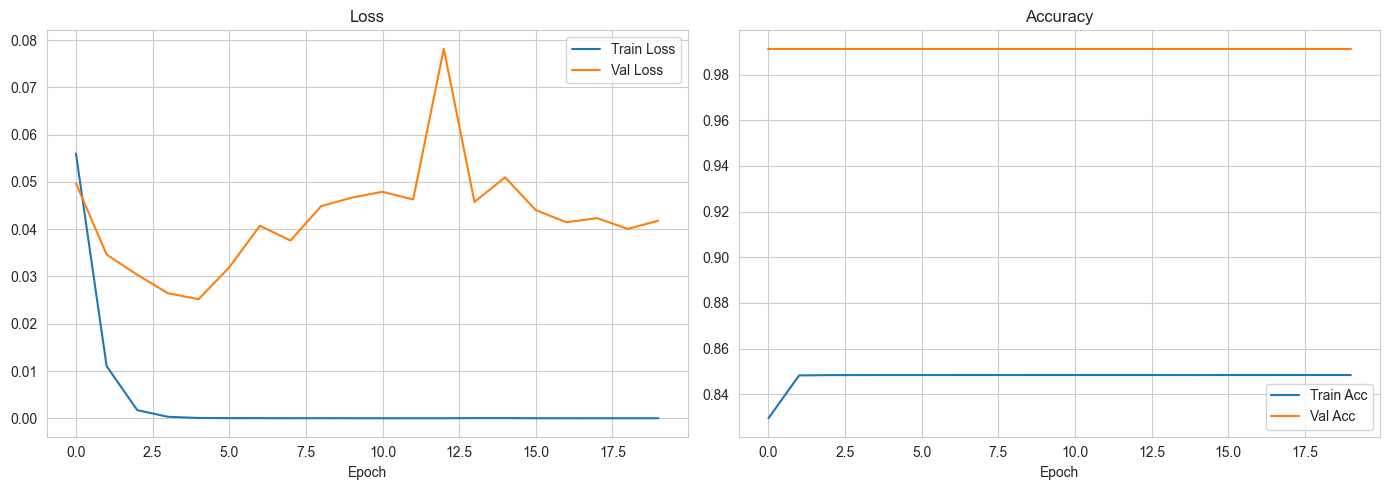

Trained for 20 epochs


In [11]:
print("Training TCN...")
history = model.fit(
    X_train_seg, y_train_seg,
    epochs=CONFIG.tcn_epochs,
    batch_size=CONFIG.tcn_batch_size,
    validation_data=(X_val_seg, y_val_seg),
    callbacks=[
        EarlyStopping('val_loss', patience=CONFIG.tcn_patience, restore_best_weights=True),
        ReduceLROnPlateau('val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ],
    verbose=1
)

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history.history['accuracy'], label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()
print(f"Trained for {len(history.history['loss'])} epochs")

## 12. Evaluate on Test Sessions

In [12]:
def predict_session_tcn(model, session, seg_len, overlap):
    """Predict on a full session by stitching overlapping segments."""
    X = session['X']
    pred_sum = np.zeros(len(X))
    pred_cnt = np.zeros(len(X))
    stride = seg_len - overlap

    for i in range((len(X) - seg_len) // stride + 1):
        start = i * stride
        end = start + seg_len
        if end <= len(X):
            segment = X[start:end].reshape(1, seg_len, -1)
            pred = model.predict(segment, verbose=0)[0, :, 0]
            pred_sum[start:end] += pred
            pred_cnt[start:end] += 1

    # Handle tail end that doesn't fit a full segment
    if pred_cnt[-1] == 0 and len(X) >= seg_len:
        start = len(X) - seg_len
        segment = X[start:].reshape(1, seg_len, -1)
        pred = model.predict(segment, verbose=0)[0, :, 0]
        pred_sum[start:] += pred
        pred_cnt[start:] += 1

    return np.divide(pred_sum, pred_cnt, where=pred_cnt > 0)


print("Evaluating on test sessions...\n")

test_results = []
for session_info in test_sessions_data:
    X = session_info['X']
    y_true = session_info['y']
    n_intervals = session_info['n_intervals']

    y_pred_proba = predict_session_tcn(model, session_info, CONFIG.segment_length, CONFIG.segment_overlap)
    peaks = detect_peaks_with_constraint(y_pred_proba, n_intervals, CONFIG)

    y_pred = np.zeros(len(y_pred_proba), dtype=int)
    y_pred[peaks] = 1

    metrics = evaluate_with_tolerance(y_true, y_pred, 10, 10)
    metrics['session'] = session_info['session']
    metrics['athlete'] = session_info['athlete']
    metrics['y_true'] = y_true
    metrics['y_pred'] = y_pred
    metrics['y_pred_proba'] = y_pred_proba
    metrics['df'] = session_info['df']
    test_results.append(metrics)

    print(f"{metrics['athlete']:12s} | {metrics['session'][:30]:30s}")
    print(f"   F_beta(2:1): {metrics['f_beta']:.3f} | P: {metrics['precision']:.3f} | R: {metrics['recall']:.3f} | Error: {metrics['mean_error_sec']:.1f}s")
    print(f"   Intervals: {metrics['n_pred']}/{metrics['n_true']}\n")

avg_f_beta = np.mean([r['f_beta'] for r in test_results])
avg_precision = np.mean([r['precision'] for r in test_results])
avg_recall = np.mean([r['recall'] for r in test_results])
avg_error = np.mean([r['mean_error_sec'] for r in test_results])

print("\n" + "="*70)
print("OVERALL TEST PERFORMANCE (-10s & +10s tolerance)")
print("="*70)
print(f"  F_beta Score (2:1 recall):  {avg_f_beta:.3f}")
print(f"  Precision: {avg_precision:.3f}")
print(f"  Recall:    {avg_recall:.3f}")
print(f"  Avg Error: {avg_error:.1f} seconds")
print("="*70)

Evaluating on test sessions...

Athlete12    | 13983533934_Technik__30er     
   F_beta(2:1): 0.091 | P: 0.091 | R: 0.091 | Error: 345.7s
   Intervals: 11/11

Athlete12    | 11846980624_Platt_            
   F_beta(2:1): 0.100 | P: 0.100 | R: 0.100 | Error: 54.0s
   Intervals: 10/10

Athlete12    | 11962243206_Wundmanagement    
   F_beta(2:1): 0.083 | P: 0.083 | R: 0.083 | Error: 111.2s
   Intervals: 12/12

Athlete12    | 12846436186_Synchronflug      
   F_beta(2:1): 0.333 | P: 0.333 | R: 0.333 | Error: 27.7s
   Intervals: 3/3

Athlete12    | 12069656901_Schwitzen_im_Sitze
   F_beta(2:1): 0.143 | P: 0.143 | R: 0.143 | Error: 186.4s
   Intervals: 7/7

Athlete12    | 13688068283_Luftpresser       
   F_beta(2:1): 0.182 | P: 0.182 | R: 0.182 | Error: 75.1s
   Intervals: 11/11

Athlete12    | 12036692734_Exhausted         
   F_beta(2:1): 0.111 | P: 0.111 | R: 0.111 | Error: 125.1s
   Intervals: 9/9

Athlete12    | 14089880174_Zn_IKEA           
   F_beta(2:1): 0.125 | P: 0.125 | R: 0.12

## 13. Visualize All Test Sessions

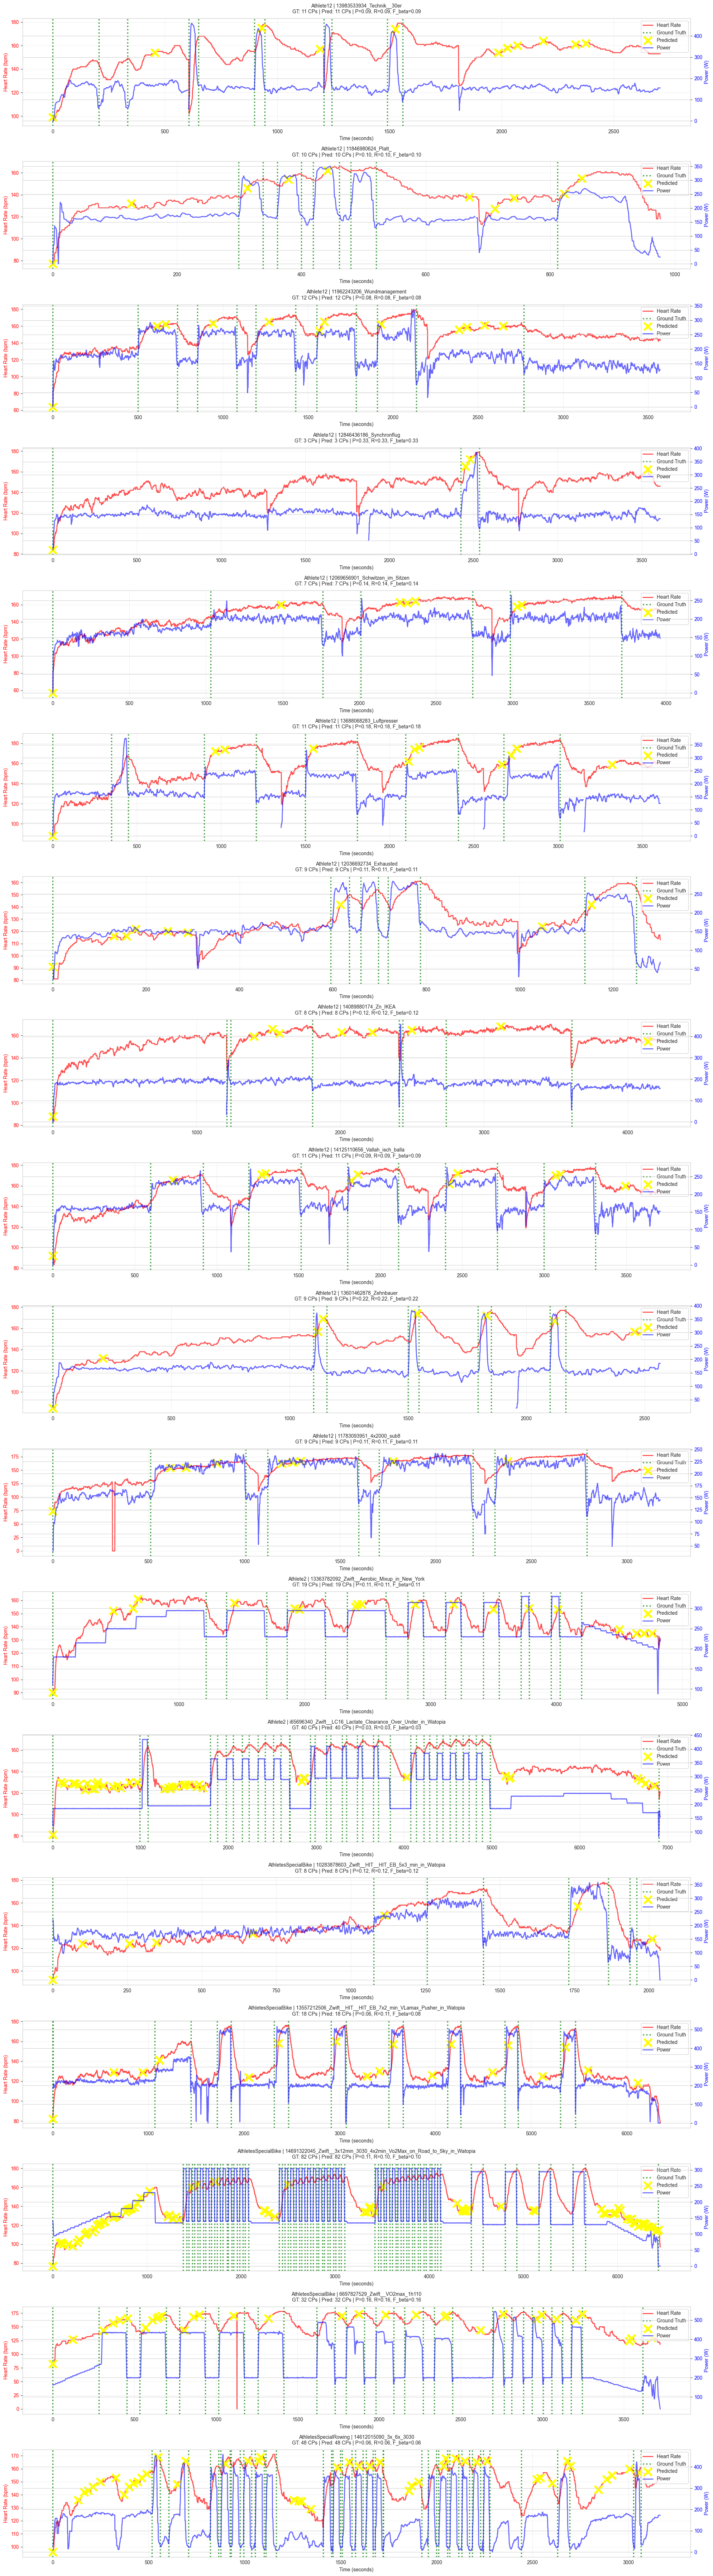

In [13]:
# Create subplots for all test sessions
n_sessions = len(test_results)
fig, axes = plt.subplots(n_sessions, 1, figsize=(20, 4*n_sessions))

# Handle case where there's only one session
if n_sessions == 1:
    axes = [axes]

for idx, result in enumerate(test_results):
    df = result['df']
    y_true = result['y_true']
    y_pred = result['y_pred']
    
    hr_values = df['heart_rate'].values
    
    # Create twin axis for power
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    # Plot heart rate on left axis (RED)
    ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

    # Plot power on right axis (BLUE)
    if 'power' in df.columns:
        power_values = df['power'].values
        ax2.plot(power_values, label='Power', color='blue', alpha=0.6, linewidth=2)
        ax2.set_ylabel('Power (W)', fontsize=10, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    # Get change points
    gt_cps = np.where(y_true == 1)[0]
    pred_cps = np.where(y_pred == 1)[0]

    # Mark ground truth change points with GREEN vertical dotted lines
    for cp in gt_cps:
        if cp < len(hr_values):
            ax1.axvline(x=cp, color='green', linestyle=':', linewidth=2.5,
                       alpha=0.8, zorder=4, label='Ground Truth' if cp == gt_cps[0] else '')

    # Mark predicted change points with YELLOW X
    for cp in pred_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='x', s=250, color='yellow',
                       linewidths=4, zorder=5, label='Predicted' if cp == pred_cps[0] else '')

    # Set title with session info and metrics
    ax1.set_title(
        f"{result['athlete']} | {result['session']}\n"
        f"GT: {result['n_true']} CPs | Pred: {result['n_pred']} CPs | "
        f"P={result['precision']:.2f}, R={result['recall']:.2f}, F_beta={result['f_beta']:.2f}",
        fontsize=10, pad=10
    )

    ax1.set_ylabel('Heart Rate (bpm)', fontsize=10, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    else:
        ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 14. Summary Statistics


✓ Created df_results with 18 test sessions
   Sports breakdown:
     rowing: 12 sessions
     biking: 6 sessions

📊 Preview of df_results:
     athlete                          session   sport  n_intervals    f_beta  \
0  Athlete12        13983533934_Technik__30er  rowing           11  0.090909   
1  Athlete12               11846980624_Platt_  rowing           10  0.100000   
2  Athlete12       11962243206_Wundmanagement  rowing           12  0.083333   
3  Athlete12         12846436186_Synchronflug  rowing            3  0.333333   
4  Athlete12  12069656901_Schwitzen_im_Sitzen  rowing            7  0.142857   

   mean_error_sec  
0      345.727273  
1       54.000000  
2      111.166667  
3       27.666667  
4      186.428571  


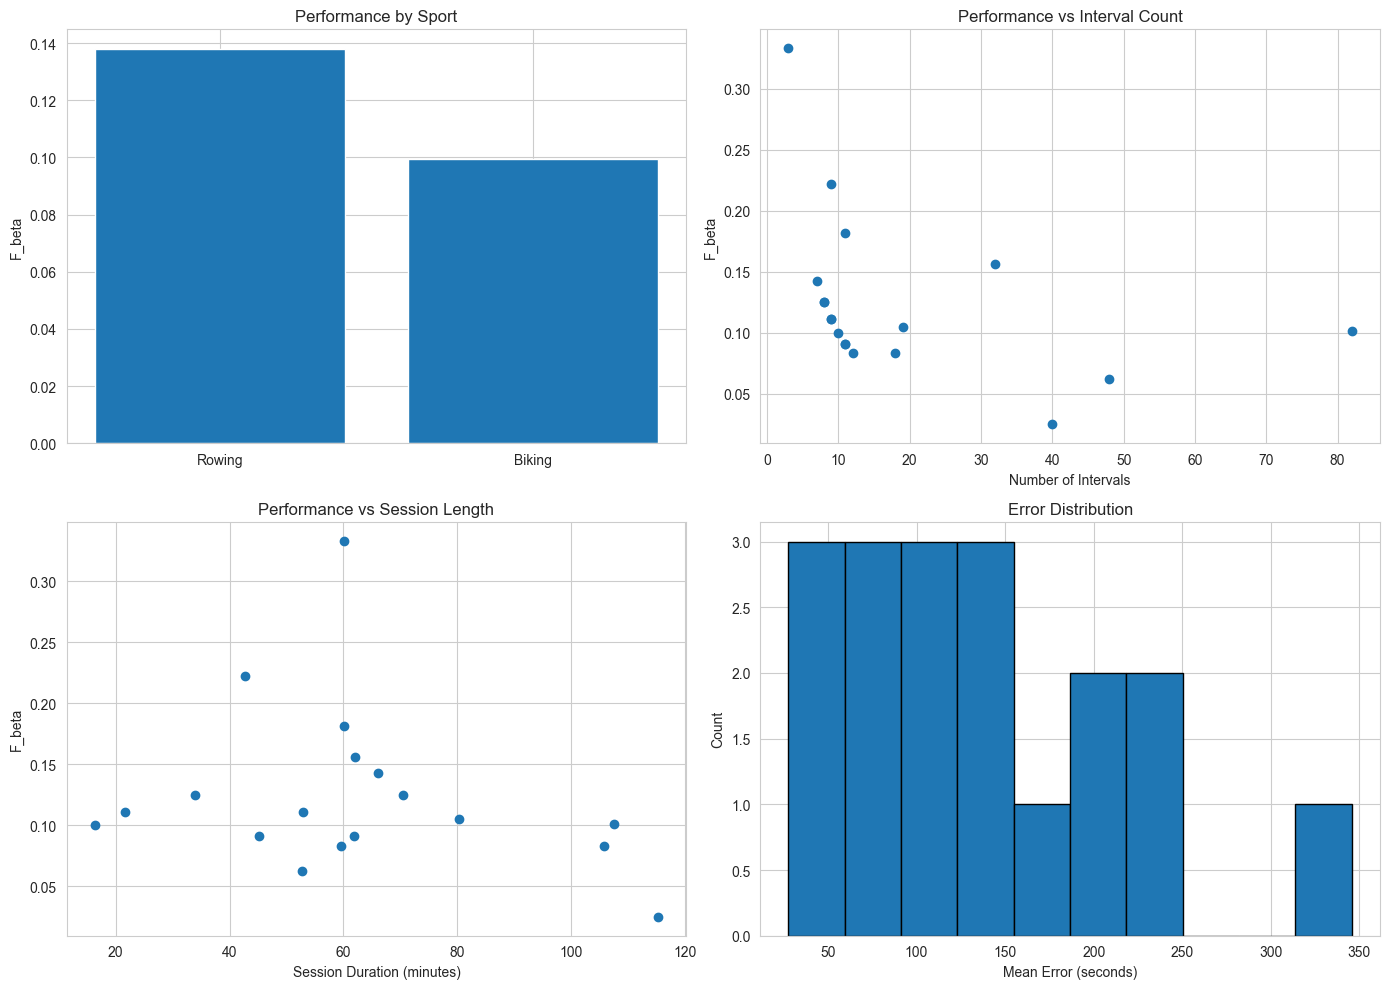

In [14]:
import matplotlib.pyplot as plt
# Create df_results from test_results
import pandas as pd

# Create a mapping from athlete name to sport
athlete_sport_mapping = {
    athlete_name: athlete_data['sport']
    for athlete_name, athlete_data in athletes.items()
}

df_results = pd.DataFrame([
    {
        'athlete': r['athlete'],
        'session': r['session'],
        'n_intervals': r['n_true'],
        'n_pred': r['n_pred'],
        'f_beta': r['f_beta'],
        'precision': r['precision'],
        'recall': r['recall'],
        'mean_error_sec': r['mean_error_sec'],
        'duration_sec': len(r['y_true']),
        'duration_min': len(r['y_true']) / 60,
        'sport': athlete_sport_mapping.get(r['athlete'], 'unknown')
    }
    for r in test_results
])

print(f"\n✓ Created df_results with {len(df_results)} test sessions")
print(f"   Sports breakdown:")
for sport, count in df_results['sport'].value_counts().items():
    print(f"     {sport}: {count} sessions")

print(f"\n📊 Preview of df_results:")
print(df_results[['athlete', 'session', 'sport', 'n_intervals', 'f_beta', 'mean_error_sec']].head())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. F_beta by sport
axes[0, 0].bar(['Rowing', 'Biking'],
               [df_results[df_results['sport']=='rowing']['f_beta'].mean(),
                df_results[df_results['sport']=='biking']['f_beta'].mean()])
axes[0, 0].set_ylabel('F_beta')
axes[0, 0].set_title('Performance by Sport')

# 2. F_beta vs number of intervals
axes[0, 1].scatter(df_results['n_intervals'], df_results['f_beta'])
axes[0, 1].set_xlabel('Number of Intervals')
axes[0, 1].set_ylabel('F_beta')
axes[0, 1].set_title('Performance vs Interval Count')

# 3. F_beta vs session duration
axes[1, 0].scatter(df_results['duration_min'], df_results['f_beta'])
axes[1, 0].set_xlabel('Session Duration (minutes)')
axes[1, 0].set_ylabel('F_beta')
axes[1, 0].set_title('Performance vs Session Length')

# 4. Error distribution
axes[1, 1].hist(df_results['mean_error_sec'], bins=10, edgecolor='black')
axes[1, 1].set_xlabel('Mean Error (seconds)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Error Distribution')

plt.tight_layout()
plt.show()

## 15. Save Results

In [15]:
import pickle

tcn_results = {
    'model_name': 'TCN_Dilated',
    'results': test_results,
}

with open('results/tcn_dilated_results.pkl', 'wb') as f:
    pickle.dump(tcn_results, f)

print(f"Saved {len(test_results)} TCN results")

Saved 18 TCN results
